### v2

**Changelog (v1 → v2)**: reproducible runs/<model>_<timestamp>/ outputs, best/last checkpoints, warmup+cosine LR, focal/weighted loss options, val-only multi-threshold metrics, epoch-wise prediction viz, and post-train evaluation/export.

## 1. Install deps (run once)

In [1]:
!pip install keras keras-hub

In [2]:
!pip install tensorflow-text

In [3]:
!lscpu

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             46 bits physical, 48 bits virtual
  Byte Order:                Little Endian
CPU(s):                      4
  On-line CPU(s) list:       0-3
Vendor ID:                   GenuineIntel
  Model name:                Intel(R) Xeon(R) CPU @ 2.00GHz
    CPU family:              6
    Model:                   85
    Thread(s) per core:      2
    Core(s) per socket:      2
    Socket(s):               1
    Stepping:                3
    BogoMIPS:                4000.43
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ss h
                             t syscall nx pdpe1gb rdtscp lm constant_tsc rep_goo
                             d nopl xtopology nonstop_tsc cpuid tsc_known_freq p
                             ni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2ap
                   

In [4]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:            31Gi       850Mi        27Gi       2.0Mi       3.5Gi        30Gi
Swap:             0B          0B          0B


In [5]:
!python --version

Python 3.12.12


In [6]:
!pip list

Package                                  Version
---------------------------------------- -------------------
absl-py                                  1.4.0
absolufy-imports                         0.3.1
accelerate                               1.11.0
aiofiles                                 22.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.2
aiosignal                                1.4.0
aiosqlite                                0.22.0
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.4.3
altair                                   5.5.0
annotated-types                          0.7.0
ansicolors                               1.1.8
antlr4-python3-runtime                   4.9.3
anyio                                    4.12.0
anywidget                            

In [7]:
import jax

# Check available devices
devices = jax.devices()
print(f"Available JAX devices: {devices}")
print(f"Number of devices: {jax.device_count()}")

# # Assert that you are using a TPU
# assert any("tpu" in device.device_kind.lower() for device in devices)

Available JAX devices: [CudaDevice(id=0)]
Number of devices: 1


## 2 pre: Fixes

In [8]:
import json
from pathlib import Path

# ----------------------------
# EDIT THESE 3 LINES ONLY
# ----------------------------
# MANIFEST_TRAIN_IN = Path("/kaggle/input/synthetic-panel-annotation-seg-v1-0-1k-data/v1.0--1k/manifest_train.jsonl")
# MANIFEST_VAL_IN   = Path("/kaggle/input/synthetic-panel-annotation-seg-v1-0-1k-data/v1.0--1k/manifest_val.jsonl")
# STRIP_PREFIX = "out/synth_ann/v1.0--1k/"   # optional; can be None

MANIFEST_TRAIN_IN = Path("/kaggle/input/synthetic-panel-annotation-seg-v1-1-10k-data/v1.1--10k/manifest_train.jsonl")
MANIFEST_VAL_IN   = Path("/kaggle/input/synthetic-panel-annotation-seg-v1-1-10k-data/v1.1--10k/manifest_val.jsonl")
STRIP_PREFIX = "out/synth_ann/v1.1--10k/"   # optional; can be None

# These are the keys present in YOUR manifest
PATH_KEYS = ["image", "mask", "meta"]  # add more if needed

OUT_DIR = Path("/kaggle/working/fixed_manifests")
OUT_DIR.mkdir(parents=True, exist_ok=True)
MANIFEST_TRAIN_OUT = OUT_DIR / "manifest_train.fixed.jsonl"
MANIFEST_VAL_OUT   = OUT_DIR / "manifest_val.fixed.jsonl"

def fix_path(p: str, strip_prefix: str | None) -> str:
    if not isinstance(p, str):
        return p
    p = p.replace("\\", "/").lstrip("./")

    # 1) strip known prefix if it matches
    if strip_prefix:
        sp = strip_prefix.replace("\\", "/")
        if not sp.endswith("/"):
            sp += "/"
        if p.startswith(sp):
            p = p[len(sp):]

    # 2) robust fallback: keep only from train/ or val/ onward
    if "train/" in p:
        p = p[p.index("train/"):]
    elif "val/" in p:
        p = p[p.index("val/"):]

    return p

def rewrite_manifest(in_path: Path, out_path: Path, strip_prefix: str | None) -> None:
    changed_lines = 0
    total = 0

    with in_path.open("r", encoding="utf-8") as fin, out_path.open("w", encoding="utf-8") as fout:
        for line in fin:
            line = line.strip()
            if not line:
                continue
            total += 1
            ex = json.loads(line)

            before = {k: ex.get(k) for k in PATH_KEYS}
            for k in PATH_KEYS:
                if k in ex:
                    ex[k] = fix_path(ex[k], strip_prefix)

            after = {k: ex.get(k) for k in PATH_KEYS}
            if before != after:
                changed_lines += 1

            fout.write(json.dumps(ex, ensure_ascii=False) + "\n")

    print(f"[OK] {in_path.name} -> {out_path} | total={total} changed_lines={changed_lines}")

rewrite_manifest(MANIFEST_TRAIN_IN, MANIFEST_TRAIN_OUT, STRIP_PREFIX)
rewrite_manifest(MANIFEST_VAL_IN,   MANIFEST_VAL_OUT,   STRIP_PREFIX)

print("\nUse these in CONFIG:")
print("CONFIG['data']['train_manifest'] =", str(MANIFEST_TRAIN_OUT))
print("CONFIG['data']['val_manifest']   =", str(MANIFEST_VAL_OUT))

print("\nSample fixed lines:")
for p in [MANIFEST_TRAIN_OUT, MANIFEST_VAL_OUT]:
    print(f"\n== {p.name} ==")
    with p.open("r", encoding="utf-8") as f:
        for _ in range(3):
            print(f.readline().rstrip())


[OK] manifest_train.jsonl -> /kaggle/working/fixed_manifests/manifest_train.fixed.jsonl | total=10000 changed_lines=10000
[OK] manifest_val.jsonl -> /kaggle/working/fixed_manifests/manifest_val.fixed.jsonl | total=2000 changed_lines=2000

Use these in CONFIG:
CONFIG['data']['train_manifest'] = /kaggle/working/fixed_manifests/manifest_train.fixed.jsonl
CONFIG['data']['val_manifest']   = /kaggle/working/fixed_manifests/manifest_val.fixed.jsonl

Sample fixed lines:

== manifest_train.fixed.jsonl ==
{"sample_id": "train_000000", "split": "train", "panel_type": "microscopy", "image": "train/part_0000/train_000000.png", "mask": "train/part_0000/train_000000_ann.png", "meta": "train/part_0000/train_000000.json", "H": 400, "W": 400, "annotation_area_pct": 2.3362499999999855}
{"sample_id": "train_000001", "split": "train", "panel_type": "blot", "image": "train/part_0000/train_000001.png", "mask": "train/part_0000/train_000001_ann.png", "meta": "train/part_0000/train_000001.json", "H": 251, "W":

## 2: JAX backend + Data distribution + Mixed Precision

In [9]:
import os
os.environ["KERAS_BACKEND"] = "jax"
# os.environ["KERAS_BACKEND"] = "tensorflow"

import json
import numpy as np

import keras
import keras.ops as ops
import keras_hub
import jax

import tensorflow as tf

print("Keras backend:", keras.backend.backend())
print("Policy:", keras.mixed_precision.global_policy())
print("TF:", tf.__version__)

2025-12-26 18:49:49.161538: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766774989.346061      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766774989.412017      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766774989.835107      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766774989.835150      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766774989.835153      55 computation_placer.cc:177] computation placer alr

Keras backend: jax
Policy: <DTypePolicy "float32">
TF: 2.19.0


In [10]:
import re
import jax
import keras

# --- Customize these lists (match by substring, case-insensitive) ---
ALLOWED_GPU_SUBSTR = [
    "t4", "p100", "v100", "a100", "h100", "l4", "a10", "a40", "a30", "rtx", "quadro"
]
NOT_SUPPORTED_GPU_SUBSTR = [
    "k80", "m60"  # add more if you want to hard-block mixed_float16
]

def _matches_any(substr_list, text: str) -> bool:
    t = (text or "").lower()
    return any(s.lower() in t for s in substr_list)

devices = jax.local_devices()
num_devices = len(devices)

platforms = sorted({d.platform for d in devices})
print("JAX platforms:", platforms)
print("Local device count:", num_devices)
for d in devices:
    print(d, "| platform:", d.platform, "| device_kind:", getattr(d, "device_kind", None))

# Prefer TPU > GPU > CPU if mixed
if "tpu" in platforms:
    primary_platform = "tpu"
elif "gpu" in platforms:
    primary_platform = "gpu"
elif "cpu" in platforms:
    primary_platform = "cpu"
else:
    primary_platform = "unknown"

# --- Mixed precision policy selection ---
policy_to_set = None

if primary_platform == "tpu":
    # TPU: recommended policy
    policy_to_set = "mixed_bfloat16"
    print("Detected TPU -> enabling mixed_bfloat16")

# T4 gpu caused NAN in kaggle so disabling it
# elif primary_platform == "gpu":
#     # Grab a representative GPU kind string
#     gpu_dev = next(d for d in devices if d.platform == "gpu")
#     gpu_kind = getattr(gpu_dev, "device_kind", None) or str(gpu_dev)

#     if _matches_any(NOT_SUPPORTED_GPU_SUBSTR, gpu_kind):
#         # Explicitly disable mixed precision
#         policy_to_set = "float32"
#         print(f"GPU '{gpu_kind}' is in NOT_SUPPORTED list -> forcing float32 (mixed precision OFF)")
#     elif _matches_any(ALLOWED_GPU_SUBSTR, gpu_kind):
#         policy_to_set = "mixed_float16"
#         print(f"GPU '{gpu_kind}' is in ALLOWED list -> enabling mixed_float16")
#     else:
#         print(
#             f"GPU '{gpu_kind}' not recognized (neither allowed nor blocked).\n"
#             "Skipping mixed_float16 for safety. Add it to ALLOWED_GPU_SUBSTR if you want."
#         )

elif primary_platform == "cpu":
    print("Detected CPU -> skipping mixed precision")

else:
    print("Unknown device platform -> skipping mixed precision")

# Apply mixed precision policy if decided
if policy_to_set is not None:
    keras.mixed_precision.set_global_policy(policy_to_set)
    print("New Keras policy:", keras.mixed_precision.global_policy())

# --- Data parallelism if multiple local devices ---
if num_devices > 1:
    data_parallel = keras.distribution.DataParallel()
    keras.distribution.set_distribution(data_parallel)
    print("Enabled Keras DataParallel across local devices.")
else:
    print("Single device -> DataParallel not enabled.")


JAX platforms: ['gpu']
Local device count: 1
cuda:0 | platform: gpu | device_kind: Tesla P100-PCIE-16GB
Unknown device platform -> skipping mixed precision
Single device -> DataParallel not enabled.


## 3. CONFIG (edit this)

In [11]:
import tensorflow as tf

CONFIG = {
    # ----------------------------
    # Run / output management
    # ----------------------------
    "run": {
        # Base directory for all experiment runs
        "base_dir": "/kaggle/working/runs",
        # Optional short tag to append to the run folder name (e.g., "exp1", "debug")
        "tag": "",
        # Optional notes (saved into config.json)
        "notes": "",
    },

    # ----------------------------
    # Data
    # ----------------------------
    "data": {
        # Set these to your generated manifests
        "train_manifest": "/kaggle/working/fixed_manifests/manifest_train.fixed.jsonl",
        "val_manifest":   "/kaggle/working/fixed_manifests/manifest_val.fixed.jsonl",

        # If your manifest paths are relative, set a root ("" means use as-is)
        # "root_dir": "/kaggle/input/synthetic-panel-annotation-seg-v1-0-1k-data/v1.0--1k",
        "root_dir": "/kaggle/input/synthetic-panel-annotation-seg-v1-1-10k-data/v1.1--10k",

        # Target square size
        "target_size": 512,

        # How to pad to square after resize-down-only
        # pad_mode: "constant" | "reflect"
        "pad_mode": "constant",
        "pad_value": 0.0,
    },

    # ----------------------------
    # Model (backbone scaling: b0..b5)
    # ----------------------------
    "model": {
        # Use "segformer_b0" .. "segformer_b5" OR "deeplabv3plus" OR "basnet_duts"
        "name": "segformer_b3",
        "num_classes": 2,  # binary => background + overlay

        # If set, this overrides presets[name]
        "preset": None,

        # Presets (KerasHub)
        "presets": {
            # SegFormer variants (ADE20K, 512)
            "segformer_b0": "segformer_b0_ade20k_512",
            "segformer_b1": "segformer_b1_ade20k_512",
            "segformer_b2": "segformer_b2_ade20k_512",
            "segformer_b3": "segformer_b3_ade20k_512",
            "segformer_b4": "segformer_b4_ade20k_512",
            "segformer_b5": "segformer_b5_ade20k_512",

            # DeepLab baseline
            "deeplabv3plus": "deeplab_v3_plus_resnet50_pascalvoc",

            # basnet
            "basnet": "basnet_duts",
        },
    },

    # ----------------------------
    # Training
    # ----------------------------
    "train": {
        "seed": 1337,
        "batch_size": 8,
        "epochs": 25,

        # steps_per_epoch/val_steps: None => auto from manifest length
        "steps_per_epoch": None,
        "val_steps": None,

        # Data pipeline
        "num_workers": tf.data.AUTOTUNE,

        # Keras compile performance knobs
        "steps_per_execution": 1,

        # Optimizer selection (default AdamW)
        "optimizer": {
            "name": "adamw",           # "adamw" | "adam"
            "lr": 3e-4,
            "weight_decay": 1e-4,      # ignored for Adam
            "global_clipnorm": 1.0,
        },

        # LR schedule (replaces ReduceLROnPlateau)
        "lr_schedule": {
            "name": "warmup_cosine",   # "none" | "warmup_cosine"
            "warmup_steps": 1000,
            "min_lr_ratio": 0.05,
        },
    },

    # ----------------------------
    # TensorBoard (optional, default on)
    # ----------------------------
    "tb": {
        "enable": True,
        "update_freq": "epoch",
        "profile_batch": 0,
    },

    # ----------------------------
    # Validation-only threshold metrics (multi-threshold / PR-ish)
    # ----------------------------
    "val_epoch_threshold_metrics": {
        "enable": False,
        "every_n_epochs": 1,
        "batches": 30,  # number of val batches to evaluate (keep modest for speed)
        "thresholds": [0.3, 0.5, 0.7],
        "compute_edges": True,
    },

    # ----------------------------
    # Prediction monitoring callback (ghost + diff + zoom patches)
    # ----------------------------
    "viz": {
        "enable": True,
        "every_n_epochs": 1,
        "num_samples": 8,     # fixed val samples used for monitoring
        "threshold": 0.5,
        "zoom": {
            "enable": True,
            "patch_size": 256,
            "max_patches": 6,
            "pad": 24,
        },
    },

    # ----------------------------
    # Augmentations (each has its own probability + ranges)
    # ----------------------------
    "aug": {
        "enable": True,

        # Rotations / flips
        "p_rot90": 0.50,     # choose k in {0,1,2,3}
        "p_flip_lr": 0.50,
        "p_flip_ud": 0.15,

        # Crop (only applied if long_side > target_size)
        "crop": {
            "enable": True,
            "p_crop": 0.35,          # overall probability to do a crop at all
            "frac_min": 0.50,        # same fraction for H and W (preserves aspect ratio)
            "frac_max": 0.95,
        },

        # Uniform scale + translate (no stretching)
        "affine": {
            "enable": True,
            "p_affine": 0.35,
            "scale_min": 0.90,       # uniform scale
            "scale_max": 1.10,
            "translate_frac": 0.08,  # max shift as fraction of target_size (applied after scaling)
        },

        # Photometric realism (image only)
        "photo": {
            "enable": True,
            "p": 0.60,
            "brightness_delta": 0.08,
            "contrast_min": 0.85,
            "contrast_max": 1.20,
            "gamma_min": 0.85,
            "gamma_max": 1.15,
            "noise_std_max": 0.02,
        },

        # JPEG compression artifacts (image only)
        "jpeg": {
            "enable": True,
            "p": 0.35,
            "quality_min": 50,
            "quality_max": 100,
        },
    },

    # ----------------------------
    # Loss (CE + Dice + Edge) + class imbalance handling
    # ----------------------------
    "loss": {
        "w_ce": 1.0,
        "w_dice": 0.7,
        "w_edge": 0.3,

        # Class imbalance handling on the CE term:
        #   - "ce": standard SparseCategoricalCrossentropy
        #   - "focal": focal CE (recommended default for sparse overlays)
        #   - "weighted": weighted CE with pos_weight
        "ce_mode": "focal",
        "focal_gamma": 2.0,
        "focal_alpha_fg": 0.75,  # alpha for foreground pixels (background gets 1-alpha)
        "pos_weight": None,      # used only when ce_mode="weighted" (e.g. 5.0)

        # Boundary-first weighting schedule (optional)
        "edge_weight_schedule": {
            "enable": True,
            "start_w_edge": 0.60,
            "end_w_edge": 0.30,
            "warmup_epochs": 3,
        },

        "eps": 1e-6,
    },
    
    "post_train": {
        "enable": True,
    
        # How many val batches to use for sweep/eval (None => use full val_steps)
        "max_val_batches": None,
    
        # Threshold sweep
        "thresholds": [round(x, 2) for x in np.linspace(0.05, 0.95, 19)],
        "optimize_metric": "dice",  # "dice" | "edge_dice" | "combo"
        "combo_weights": {"dice": 0.7, "edge_dice": 0.3},
        "compute_edge_metrics": True,
    
        # Worst-case dump
        "worst_k": 50,
        "worst_select_threshold": 0.50,  # used only to SELECT worst-K during sweep pass
        "viz_threshold": "best",         # "best" | float
        "zoom": {
            "enable": True,
            "patch_size": 256,
            "max_patches": 6,
            "pad": 24,
            "seed": 1337,
        },
    
        # Export package
        "export": {"enable": True},
    
        # Speed benchmark
        "speed": {
            "enable": True,
            "warmup_batches": 1,
            "batches": 10,
        }
    },
}


In [12]:
# Reproducability
keras.utils.set_random_seed(CONFIG["train"]["seed"])
tf.random.set_seed(CONFIG["train"]["seed"])

## 3.1 Run folder, LR schedule, optimizer factory

In [13]:
import sys
import keras
import keras.ops as ops
import tensorflow as tf
import jax
import numpy as np
import os
import re
import json
import time
import platform
import datetime
from pathlib import Path

def _safe_name(s: str) -> str:
    s = str(s)
    s = re.sub(r"[^A-Za-z0-9_.-]+", "-", s).strip("-")
    return s or "run"

def make_run_dir(cfg: dict) -> Path:
    base = Path(cfg["run"]["base_dir"]).expanduser()
    base.mkdir(parents=True, exist_ok=True)

    ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    model_name = _safe_name(cfg["model"]["name"])
    tag = _safe_name(cfg["run"].get("tag", ""))
    run_name = f"{model_name}_{ts}" + (f"_{tag}" if tag else "")

    run_dir = base / run_name
    run_dir.mkdir(parents=True, exist_ok=False)

    # Standard subfolders
    (run_dir / "checkpoints").mkdir(parents=True, exist_ok=True)
    (run_dir / "viz").mkdir(parents=True, exist_ok=True)
    (run_dir / "tb").mkdir(parents=True, exist_ok=True)

    return run_dir

def collect_env_info() -> dict:
    info = {
        "timestamp": datetime.datetime.now().isoformat(),
        "python": sys.version,
        "platform": platform.platform(),
        "keras_backend": keras.backend.backend(),
        "keras_version": getattr(keras, "__version__", None),
        "tensorflow_version": getattr(tf, "__version__", None),
        "jax_version": getattr(jax, "__version__", None),
        "numpy_version": getattr(np, "__version__", None),
    }
    try:
        info["jax_local_device_count"] = int(jax.local_device_count())
        info["jax_global_device_count"] = int(jax.device_count())
        info["jax_process_count"] = int(jax.process_count())
        info["jax_process_index"] = int(jax.process_index())
    
        devs = jax.devices()
        info["jax_devices"] = [str(d) for d in devs]
        info["jax_device_kinds"] = [getattr(d, "device_kind", None) for d in devs]   # <- key addition
        info["jax_device_platforms"] = [getattr(d, "platform", None) for d in devs]
    except Exception as e:
        info["jax_device_error"] = str(e)
    
    try:
        info["tf_physical_devices"] = [f"{d.device_type}:{d.name}" for d in tf.config.list_physical_devices()]
    except Exception as e:
        info["tf_device_error"] = str(e)
        
    return info

def make_jsonable(x):
    """Best-effort conversion to something JSON serializable."""
    if isinstance(x, (str, int, float, bool)) or x is None:
        return x
    if isinstance(x, Path):
        return str(x)
    if isinstance(x, (list, tuple)):
        return [make_jsonable(v) for v in x]
    if isinstance(x, dict):
        return {str(k): make_jsonable(v) for k, v in x.items()}
    # TensorFlow / JAX / NumPy / others
    try:
        import numpy as _np
        if isinstance(x, _np.generic):
            return x.item()
    except Exception:
        pass
    return str(x)

def write_json(path: Path, obj: dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(make_jsonable(obj), f, indent=2, sort_keys=False)

# ----------------------------
# Warmup + Cosine LR schedule
# ----------------------------
class WarmupCosine(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr: float, warmup_steps: int, total_steps: int, min_lr_ratio: float = 0.05):
        super().__init__()
        self.base_lr = float(base_lr)
        self.warmup_steps = int(max(0, warmup_steps))
        self.total_steps = int(max(1, total_steps))
        self.min_lr_ratio = float(min_lr_ratio)

    def __call__(self, step):
        step = ops.cast(step, "float32")
        base = ops.cast(self.base_lr, "float32")
        warm = ops.cast(self.warmup_steps, "float32")
        total = ops.cast(self.total_steps, "float32")
        min_lr = base * ops.cast(self.min_lr_ratio, "float32")

        # Warmup: linear 0 -> base
        def _warmup():
            return base * (step / ops.maximum(1.0, warm))

        # Cosine: base -> min_lr
        def _cosine():
            # progress in [0,1]
            t = (step - warm) / ops.maximum(1.0, (total - warm))
            t = ops.clip(t, 0.0, 1.0)
            cosine = 0.5 * (1.0 + ops.cos(ops.cast(3.141592653589793, "float32") * t))
            return min_lr + (base - min_lr) * cosine

        return ops.cond(step < warm, _warmup, _cosine)

    def get_config(self):
        return {
            "base_lr": self.base_lr,
            "warmup_steps": self.warmup_steps,
            "total_steps": self.total_steps,
            "min_lr_ratio": self.min_lr_ratio,
        }

def make_lr(cfg_train: dict, total_steps: int):
    opt_cfg = cfg_train["optimizer"]
    base_lr = float(opt_cfg["lr"])
    sch_cfg = cfg_train.get("lr_schedule", {"name": "none"})
    name = (sch_cfg.get("name") or "none").lower()

    if name in ("none", "off", "false"):
        return base_lr

    if name in ("warmup_cosine", "warmup+cosine", "warmupcosine"):
        warmup_steps = int(sch_cfg.get("warmup_steps", 0))
        min_lr_ratio = float(sch_cfg.get("min_lr_ratio", 0.05))
        return WarmupCosine(base_lr=base_lr, warmup_steps=warmup_steps, total_steps=total_steps, min_lr_ratio=min_lr_ratio)

    raise ValueError(f"Unknown lr_schedule.name: {name}")

def make_optimizer(cfg_train: dict, total_steps: int):
    opt_cfg = cfg_train["optimizer"]
    name = (opt_cfg.get("name") or "adamw").lower()

    lr = make_lr(cfg_train, total_steps=total_steps)

    clip = opt_cfg.get("global_clipnorm", None)
    clip = None if clip in (None, 0, 0.0) else float(clip)

    if name == "adamw":
        return keras.optimizers.AdamW(
            learning_rate=lr,
            weight_decay=float(opt_cfg.get("weight_decay", 0.0)),
            global_clipnorm=clip,
        )
    if name == "adam":
        return keras.optimizers.Adam(
            learning_rate=lr,
            global_clipnorm=clip,
        )

    raise ValueError(f"Unknown optimizer.name: {name}")

def save_history_csv(history: keras.callbacks.History, out_csv: Path) -> None:
    # history.history is a dict[str, list]
    import pandas as pd
    df = pd.DataFrame(history.history)
    df.to_csv(out_csv, index=False)

## 4: Manifest utilities

In [14]:
def read_jsonl_manifest(jsonl_path: str, root_dir: str = ""):
    """Returns two python lists: image_paths, mask_paths."""
    img_paths, mask_paths = [], []
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            ex = json.loads(line)
            # ip = ex["image_path"]
            # mp = ex["mask_path"]
            ip = ex["image"]
            mp = ex["mask"]
            
            if root_dir:
                if not os.path.isabs(ip):
                    ip = os.path.join(root_dir, ip)
                if not os.path.isabs(mp):
                    mp = os.path.join(root_dir, mp)
            img_paths.append(ip)
            mask_paths.append(mp)
    return img_paths, mask_paths

## 4.1  Validate manifest paths before training

- What to check
- JSONL lines parse
- required keys exist (image, mask)
- resolved file paths exist on disk
- optional: load a few images/masks to ensure shapes/mask values OK (0/255)

In [15]:
import json
from pathlib import Path
import random

def validate_manifest(
    jsonl_path: str,
    dataset_root: str,
    keys=("image", "mask"),
    max_missing_to_print=25,
    deep_check_samples=50,   # set 0 to skip loading pixels
    seed=123,
):
    """
    Validates that all referenced files exist (and optionally loads some samples).
    dataset_root: the directory that contains train/ and val/ (e.g. /kaggle/input/.../v1.0--1k)
    """
    jsonl_path = Path(jsonl_path)
    dataset_root = Path(dataset_root)

    total = 0
    missing = []
    bad_lines = 0
    bad_keys = 0
    entries = []

    with jsonl_path.open("r", encoding="utf-8") as f:
        for ln, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            total += 1
            try:
                ex = json.loads(line)
            except Exception:
                bad_lines += 1
                continue

            ok = True
            for k in keys:
                if k not in ex:
                    ok = False
            if not ok:
                bad_keys += 1
                continue

            # store for optional deep check
            entries.append(ex)

            for k in keys:
                rel = ex[k].replace("\\", "/")
                p = rel if rel.startswith("/") else str(dataset_root / rel)
                if not Path(p).exists():
                    missing.append((ln, k, rel, p))

    print(f"[VALIDATE] {jsonl_path.name}")
    print(f"  total lines: {total}")
    print(f"  bad json lines: {bad_lines}")
    print(f"  missing required keys: {bad_keys}")
    print(f"  missing files: {len(missing)}")

    if missing:
        print("\nFirst missing entries:")
        for item in missing[:max_missing_to_print]:
            ln, k, rel, p = item
            print(f"  line {ln} key={k} rel={rel} -> {p}")

    # Optional: deep check some samples by decoding image/mask
    if deep_check_samples and entries:
        import tensorflow as tf

        rng = random.Random(seed)
        picks = [entries[rng.randrange(0, len(entries))] for _ in range(min(deep_check_samples, len(entries)))]

        bad_decode = 0
        bad_mask_values = 0
        for ex in picks:
            ip = ex["image"].replace("\\", "/")
            mp = ex["mask"].replace("\\", "/")
            ip = ip if ip.startswith("/") else str(dataset_root / ip)
            mp = mp if mp.startswith("/") else str(dataset_root / mp)

            try:
                img = tf.io.decode_image(tf.io.read_file(ip), channels=3, expand_animations=False)
                msk = tf.io.decode_image(tf.io.read_file(mp), channels=1, expand_animations=False)
            except Exception:
                bad_decode += 1
                continue

            # mask should be 0/255 (allowing minor variations)
            # sample small subset of pixels for speed
            m = tf.reshape(msk, [-1])
            if tf.size(m) > 0:
                samp = tf.gather(m, tf.random.uniform((512,), 0, tf.size(m), dtype=tf.int32))
                unique = tf.unique(tf.cast(samp, tf.int32)).y.numpy().tolist()
                # if values aren't subset of {0,255}, flag
                if any(v not in (0, 255) for v in unique):
                    bad_mask_values += 1

        print("\n[DEEP CHECK]")
        print(f"  decoded failures in sampled items: {bad_decode}/{len(picks)}")
        print(f"  sampled items with non-{{0,255}} mask pixels: {bad_mask_values}/{len(picks)}")

    return {"total": total, "bad_lines": bad_lines, "bad_keys": bad_keys, "missing": len(missing)}


In [16]:
%%time
# right before building ds OR right after deciding manifest paths
DATASET_ROOT = CONFIG["data"]["root_dir"]

validate_manifest(CONFIG["data"]["train_manifest"], DATASET_ROOT, deep_check_samples=50)
validate_manifest(CONFIG["data"]["val_manifest"],   DATASET_ROOT, deep_check_samples=50)

[VALIDATE] manifest_train.fixed.jsonl
  total lines: 10000
  bad json lines: 0
  missing required keys: 0
  missing files: 0


I0000 00:00:1766775062.304338      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15505 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



[DEEP CHECK]
  decoded failures in sampled items: 0/50
  sampled items with non-{0,255} mask pixels: 0/50
[VALIDATE] manifest_val.fixed.jsonl
  total lines: 2000
  bad json lines: 0
  missing required keys: 0
  missing files: 0

[DEEP CHECK]
  decoded failures in sampled items: 0/50
  sampled items with non-{0,255} mask pixels: 0/50
CPU times: user 2.24 s, sys: 998 ms, total: 3.24 s
Wall time: 1min 18s


{'total': 2000, 'bad_lines': 0, 'bad_keys': 0, 'missing': 0}

## 5: Preprocess ops (no-upscale resize-down-only + pad)

In [17]:
def _compute_pad_offsets(h, w, target, mode: str):
    pad_h = target - h
    pad_w = target - w
    if mode == "topleft":
        top = tf.constant(0, tf.int32)
        left = tf.constant(0, tf.int32)
    else:
        top = pad_h // 2
        left = pad_w // 2
    bottom = pad_h - top
    right  = pad_w - left
    return top, bottom, left, right

def resize_down_only(image, mask, target, pad_mode, pad_value):
    """
    image: float32 [H,W,3] in 0..255
    mask : uint8/int32 [H,W,1] in 0..255
    Output: (image, mask01) both padded to [target,target,*]
    - No upscaling when long_side <= target
    - Downscale uniformly when long_side > target
    """
    h = tf.shape(image)[0]
    w = tf.shape(image)[1]
    h_f = tf.cast(h, tf.float32)
    w_f = tf.cast(w, tf.float32)

    long_side = tf.maximum(h_f, w_f)
    target_f = tf.cast(target, tf.float32)

    # scale = min(1, target/long_side)
    scale = tf.minimum(1.0, target_f / long_side)

    new_h = tf.cast(tf.round(h_f * scale), tf.int32)
    new_w = tf.cast(tf.round(w_f * scale), tf.int32)

    image_r = tf.image.resize(image, (new_h, new_w), method="bilinear", antialias=True)
    mask_r  = tf.image.resize(mask,  (new_h, new_w), method="nearest")

    # Pad to square
    top, bottom, left, right = _compute_pad_offsets(new_h, new_w, target, pad_mode)
    image_p = tf.pad(
        image_r, [[top, bottom], [left, right], [0, 0]],
        constant_values=tf.cast(pad_value, tf.float32),
    )
    mask_p = tf.pad(
        mask_r, [[top, bottom], [left, right], [0, 0]],
        constant_values=tf.cast(0, mask_r.dtype),
    )

    image_p.set_shape([target, target, 3])
    mask_p.set_shape([target, target, 1])
    return image_p, mask_p

def mask_to_class_ids(mask_0_255):
    """Convert [H,W,1] 0/255 to int32 class ids in {0,1}."""
    return tf.cast(mask_0_255 > 127, tf.int32)

## 6: Augmentations (crop on large only, rot/flip, uniform scale+translate)

In [18]:
def maybe_random_crop(image, mask, cfg, target):
    """
    Crop only if long_side > target (large images).
    Preserves aspect ratio by using a single fraction f for both H and W.
    """
    if not cfg["enable"]:
        return image, mask

    p_crop = cfg["p_crop"]
    do_crop = tf.random.uniform(()) < p_crop

    h = tf.shape(image)[0]
    w = tf.shape(image)[1]
    long_side = tf.maximum(h, w)

    def _crop():
        frac = tf.random.uniform((), cfg["frac_min"], cfg["frac_max"])
        ch = tf.cast(tf.round(tf.cast(h, tf.float32) * frac), tf.int32)
        cw = tf.cast(tf.round(tf.cast(w, tf.float32) * frac), tf.int32)

        # Ensure at least 1px
        ch = tf.maximum(1, ch)
        cw = tf.maximum(1, cw)

        max_top  = tf.maximum(0, h - ch)
        max_left = tf.maximum(0, w - cw)

        top  = tf.random.uniform((), 0, max_top + 1, dtype=tf.int32)
        left = tf.random.uniform((), 0, max_left + 1, dtype=tf.int32)

        image_c = tf.image.crop_to_bounding_box(image, top, left, ch, cw)
        mask_c  = tf.image.crop_to_bounding_box(mask,  top, left, ch, cw)
        return image_c, mask_c

    # only crop if long_side > target
    return tf.cond(do_crop & (long_side > target), _crop, lambda: (image, mask))

def maybe_rot_flip(image, mask, cfg):
    if not cfg["enable"]:
        return image, mask

    # rot90
    if cfg["p_rot90"] > 0:
        do_rot = tf.random.uniform(()) < cfg["p_rot90"]
        k = tf.random.uniform((), 0, 4, dtype=tf.int32)
        image = tf.cond(do_rot, lambda: tf.image.rot90(image, k=k), lambda: image)
        mask  = tf.cond(do_rot, lambda: tf.image.rot90(mask,  k=k), lambda: mask)

    # flip LR
    if cfg["p_flip_lr"] > 0:
        do = tf.random.uniform(()) < cfg["p_flip_lr"]
        image = tf.cond(do, lambda: tf.image.flip_left_right(image), lambda: image)
        mask  = tf.cond(do, lambda: tf.image.flip_left_right(mask),  lambda: mask)

    # flip UD
    if cfg["p_flip_ud"] > 0:
        do = tf.random.uniform(()) < cfg["p_flip_ud"]
        image = tf.cond(do, lambda: tf.image.flip_up_down(image), lambda: image)
        mask  = tf.cond(do, lambda: tf.image.flip_up_down(mask),  lambda: mask)

    return image, mask

def maybe_uniform_scale_translate_square(image, mask, cfg_affine, target, pad_value):
    """
    Apply uniform scaling (no aspect ratio change) and translation on already-square [target,target].
    Implementation:
      - resize square -> new_size
      - if new_size <= target: pad back with random offsets
      - if new_size >  target: crop back with random offsets
    """
    if (not cfg_affine["enable"]) or (cfg_affine["p_affine"] <= 0):
        return image, mask

    do = tf.random.uniform(()) < cfg_affine["p_affine"]

    def _apply():
        scale = tf.random.uniform((), cfg_affine["scale_min"], cfg_affine["scale_max"])
        new_size = tf.cast(tf.round(tf.cast(target, tf.float32) * scale), tf.int32)
        new_size = tf.maximum(1, new_size)

        img_r = tf.image.resize(image, (new_size, new_size), method="bilinear", antialias=True)
        msk_r = tf.image.resize(mask,  (new_size, new_size), method="nearest")

        max_shift = tf.cast(tf.round(cfg_affine["translate_frac"] * tf.cast(target, tf.float32)), tf.int32)

        # Case 1: shrink -> pad back
        def _pad_back():
            pad = target - new_size
            # center offsets plus random translation
            base = pad // 2

            shift_y = tf.random.uniform((), -max_shift, max_shift + 1, dtype=tf.int32)
            shift_x = tf.random.uniform((), -max_shift, max_shift + 1, dtype=tf.int32)

            top = tf.clip_by_value(base + shift_y, 0, pad)
            left = tf.clip_by_value(base + shift_x, 0, pad)
            bottom = pad - top
            right  = pad - left

            img_p = tf.pad(img_r, [[top, bottom], [left, right], [0, 0]],
                           constant_values=tf.cast(pad_value, tf.float32))
            msk_p = tf.pad(msk_r, [[top, bottom], [left, right], [0, 0]],
                           constant_values=tf.cast(0, msk_r.dtype))
            return img_p, msk_p

        # Case 2: zoom -> crop back
        def _crop_back():
            extra = new_size - target
            base = extra // 2

            # shift limited by available extra
            max_shift2 = tf.minimum(max_shift, base)

            shift_y = tf.random.uniform((), -max_shift2, max_shift2 + 1, dtype=tf.int32)
            shift_x = tf.random.uniform((), -max_shift2, max_shift2 + 1, dtype=tf.int32)

            top  = tf.clip_by_value(base + shift_y, 0, extra)
            left = tf.clip_by_value(base + shift_x, 0, extra)

            img_c = tf.image.crop_to_bounding_box(img_r, top, left, target, target)
            msk_c = tf.image.crop_to_bounding_box(msk_r, top, left, target, target)
            return img_c, msk_c

        img2, msk2 = tf.cond(new_size <= target, _pad_back, _crop_back)

        img2.set_shape([target, target, 3])
        msk2.set_shape([target, target, 1])
        return img2, msk2

    return tf.cond(do, _apply, lambda: (image, mask))

def maybe_photometric(image, cfg_photo):
    """Photometric augmentation on image only. Input is float32 0..255."""
    if (not cfg_photo.get("enable", False)) or (cfg_photo.get("p", 0) <= 0):
        return image
    do = tf.random.uniform(()) < cfg_photo["p"]

    def _apply():
        x = tf.clip_by_value(image / 255.0, 0.0, 1.0)

        # brightness
        bd = tf.cast(cfg_photo.get("brightness_delta", 0.0), tf.float32)
        if bd > 0:
            delta = tf.random.uniform((), -bd, bd)
            x = x + delta

        # contrast (around per-image mean)
        cmin = tf.cast(cfg_photo.get("contrast_min", 1.0), tf.float32)
        cmax = tf.cast(cfg_photo.get("contrast_max", 1.0), tf.float32)
        if (cmin != 1.0) or (cmax != 1.0):
            c = tf.random.uniform((), cmin, cmax)
            mean = tf.reduce_mean(x, axis=[0, 1], keepdims=True)
            x = (x - mean) * c + mean

        # gamma
        gmin = tf.cast(cfg_photo.get("gamma_min", 1.0), tf.float32)
        gmax = tf.cast(cfg_photo.get("gamma_max", 1.0), tf.float32)
        if (gmin != 1.0) or (gmax != 1.0):
            g = tf.random.uniform((), gmin, gmax)
            x = tf.pow(tf.clip_by_value(x, 0.0, 1.0), g)

        # gaussian noise
        nmax = tf.cast(cfg_photo.get("noise_std_max", 0.0), tf.float32)
        if nmax > 0:
            std = tf.random.uniform((), 0.0, nmax)
            x = x + tf.random.normal(tf.shape(x), stddev=std)

        x = tf.clip_by_value(x, 0.0, 1.0)
        return x * 255.0

    out = tf.cond(do, _apply, lambda: image)
    out.set_shape(image.shape)
    return out


def maybe_jpeg_compress(image, cfg_jpeg):
    """JPEG compression artifacts on image only.

    Notes:
      - tf.io.encode_jpeg() requires `quality` to be a Python int (op attribute),
        so we can't pass a random Tensor directly.
      - We approximate "random quality" by sampling from a small discrete set of
        quality levels between [quality_min, quality_max].
    Input is float32 in 0..255.
    """
    if (not cfg_jpeg.get("enable", False)) or (cfg_jpeg.get("p", 0) <= 0):
        return image

    # Build discrete quality ladder once (Python-side).
    qmin = int(cfg_jpeg.get("quality_min", 60))
    qmax = int(cfg_jpeg.get("quality_max", 100))
    n_levels = int(cfg_jpeg.get("quality_levels", 4))  # new optional knob
    n_levels = max(2, n_levels)
    if qmax < qmin:
        qmin, qmax = qmax, qmin

    qualities = [int(round(qmin + (qmax - qmin) * i / (n_levels - 1))) for i in range(n_levels)]

    do = tf.random.uniform(()) < float(cfg_jpeg.get("p", 0.0))

    def _apply():
        u8 = tf.cast(tf.clip_by_value(image, 0.0, 255.0), tf.uint8)
        idx = tf.random.uniform((), 0, n_levels, dtype=tf.int32)

        def _branch(q):
            enc = tf.io.encode_jpeg(u8, format="rgb", quality=q, chroma_downsampling=True)
            dec = tf.io.decode_jpeg(enc, channels=3)
            return tf.cast(dec, tf.float32)

        branch_fns = [lambda q=q: _branch(q) for q in qualities]
        out = tf.switch_case(idx, branch_fns=branch_fns, default=branch_fns[0])
        out.set_shape(image.shape)
        return out

    out = tf.cond(do, _apply, lambda: image)
    out.set_shape(image.shape)
    return out


## 7: tf.data pipeline

In [19]:
def build_dataset(manifest_path, root_dir, cfg, training: bool):
    img_paths, mask_paths = read_jsonl_manifest(manifest_path, root_dir=root_dir)
    n = len(img_paths)

    ds = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))
    if training:
        ds = ds.shuffle(min(n, 4096), seed=cfg["train"]["seed"], reshuffle_each_iteration=True)

    target = cfg["data"]["target_size"]
    pad_value = cfg["data"]["pad_value"]
    pad_mode = cfg["data"]["pad_mode"]

    aug_cfg = cfg["aug"]
    crop_cfg = aug_cfg["crop"]
    affine_cfg = aug_cfg["affine"]

    def _load(ip, mp):
        img = tf.io.decode_png(tf.io.read_file(ip), channels=3)
        img = tf.cast(img, tf.float32)  # 0..255 float
        msk = tf.io.decode_png(tf.io.read_file(mp), channels=1)
        # keep as uint8 or int32, values 0..255
        msk = tf.cast(msk, tf.uint8)
        return img, msk

    def _proc(img, msk):
        # Optional crop on original resolution (only if large)
        if training and aug_cfg["enable"] and crop_cfg["enable"]:
            img, msk = maybe_random_crop(img, msk, crop_cfg, target)

        # Resize-down-only + pad to square
        img, msk = resize_down_only(img, msk, target, pad_mode, pad_value)

        # Augmentations on square (rot/flip first)
        if training and aug_cfg["enable"]:
            img, msk = maybe_rot_flip(img, msk, aug_cfg)
            img, msk = maybe_uniform_scale_translate_square(img, msk, affine_cfg, target, pad_value)

            # Photometric + JPEG compression (image only)
            img = maybe_photometric(img, aug_cfg.get("photo", {"enable": False}))
            img = maybe_jpeg_compress(img, aug_cfg.get("jpeg", {"enable": False}))

        # Convert mask to class ids {0,1}
        y = mask_to_class_ids(msk)                 # [H,W,1] int32
        y.set_shape([target, target, 1])
        return img, y

    ds = ds.map(_load, num_parallel_calls=cfg["train"]["num_workers"])
    ds = ds.map(_proc, num_parallel_calls=cfg["train"]["num_workers"])
    ds = ds.batch(cfg["train"]["batch_size"], drop_remainder=True).prefetch(tf.data.AUTOTUNE)

    return ds, n

In [20]:
import matplotlib.pyplot as plt
import numpy as np

def show_batch_from_dataset(ds, n=4, alpha=0.35, title=""):
    """
    ds yields (image, y) where:
      image: [B,512,512,3] float32 0..255 (in our pipeline)
      y:     [B,512,512,1] int32 {0,1}
    """
    batch = next(iter(ds))
    x, y = batch
    x = x.numpy().astype(np.float32)
    y = y.numpy().astype(np.uint8)

    n = min(n, x.shape[0])
    plt.figure(figsize=(12, 3*n))
    if title:
        plt.suptitle(title)

    for i in range(n):
        img = x[i] / 255.0
        m = y[i, :, :, 0]

        # show raw image
        ax1 = plt.subplot(n, 3, 3*i + 1)
        ax1.imshow(img)
        ax1.set_title("Image (preprocessed)")
        ax1.axis("off")

        # show mask
        ax2 = plt.subplot(n, 3, 3*i + 2)
        ax2.imshow(m, cmap="gray")
        ax2.set_title("Mask (0/1)")
        ax2.axis("off")

        # overlay
        ax3 = plt.subplot(n, 3, 3*i + 3)
        ax3.imshow(img)
        ax3.imshow(m, alpha=alpha, cmap="gray")
        ax3.set_title("Overlay")
        ax3.axis("off")

    plt.tight_layout()
    plt.show()


## 8: Build model (single model at once)

In [21]:
def build_segmenter(cfg):
    """
    Basnet: https://www.kaggle.com/models/keras/basnet/keras/basnet_duts
    """
    mcfg = cfg["model"]
    name = mcfg["name"]
    num_classes = int(mcfg["num_classes"])

    preset = mcfg.get("preset", None)
    if preset is None:
        preset = mcfg["presets"][name]

    # SegFormer family
    if name.startswith("segformer"):
        model = keras_hub.models.SegFormerImageSegmenter.from_preset(
            preset, 
            num_classes=num_classes,
            preprocessor=None,
        )
        return model

    # DeepLab family
    if name.startswith("deeplab"):
        model = keras_hub.models.DeepLabV3ImageSegmenter.from_preset(
            preset, 
            num_classes=num_classes,
            preprocessor=None,
        )
        return model

    # BasNet
    if name == "basnet":
        model = keras_hub.models.BASNetImageSegmenter.from_preset(
            preset, num_classes=num_classes
        )
        return model
        
    raise ValueError(f"Unknown model.name: {name}")


## 9: Loss (CE + Dice + Edge) + metrics (Dice/IoU)
### Backend-safe: uses keras.ops only

In [22]:
import keras
import keras.ops as ops

# ----------------------------
# Helpers
# ----------------------------
def _softmax_fg(logits):
    """Return foreground probability channel as float32 [B,H,W,1]."""
    logits_f = ops.cast(logits, "float32")
    probs = ops.softmax(logits_f, axis=-1)
    return probs[..., 1:2]

def _sparse_ce_per_pixel(y_int, logits):
    """Per-pixel sparse CE. y_int: [B,H,W] int, logits: [B,H,W,C]"""
    return keras.losses.sparse_categorical_crossentropy(y_int, logits, from_logits=True)

def _ce_loss(y_int, logits, cfg_loss):
    mode = (cfg_loss.get("ce_mode") or "ce").lower()
    ce = ops.cast(_sparse_ce_per_pixel(y_int, logits), "float32")  # [B,H,W]

    if mode in ("ce", "crossentropy", "sce"):
        return ops.mean(ce)

    if mode in ("weighted", "wce"):
        pos_weight = cfg_loss.get("pos_weight", None)
        if pos_weight is None:
            # fallback to plain CE
            return ops.mean(ce)
        pos_weight = ops.cast(float(pos_weight), "float32")
        w = ops.where(y_int > 0, pos_weight, ops.cast(1.0, "float32"))
        return ops.mean(ce * w)

    if mode in ("focal", "focal_ce", "focalce"):
        gamma = ops.cast(float(cfg_loss.get("focal_gamma", 2.0)), "float32")
        alpha_fg = ops.cast(float(cfg_loss.get("focal_alpha_fg", 0.75)), "float32")
        alpha_bg = ops.cast(1.0, "float32") - alpha_fg

        # pt = exp(-ce)
        pt = ops.exp(-ce)
        alpha = ops.where(y_int > 0, alpha_fg, alpha_bg)
        focal = alpha * ops.power(ops.cast(1.0, "float32") - pt, gamma) * ce
        return ops.mean(focal)

    raise ValueError(f"Unknown loss.ce_mode: {mode}")

def dice_loss_from_probs(y_true01, p_fg, eps=1e-6):
    y_true01 = ops.cast(y_true01, "float32")
    p_fg     = ops.cast(p_fg,     "float32")

    y = ops.reshape(y_true01, (ops.shape(y_true01)[0], -1))
    p = ops.reshape(p_fg,     (ops.shape(p_fg)[0],     -1))

    inter = ops.sum(y * p, axis=-1)
    denom = ops.sum(y, axis=-1) + ops.sum(p, axis=-1)
    dice = (2.0 * inter + eps) / (denom + eps)
    return 1.0 - ops.mean(dice)

def edge_loss_finite_diff(y_true01, p_fg, eps=1e-6):
    """Edge-aware loss using finite differences on GT vs pred prob."""
    y_true01 = ops.cast(y_true01, "float32")
    p_fg     = ops.cast(p_fg,     "float32")

    # simple 1-step finite differences
    def _edges(x):
        dy = ops.abs(x[:, 1:, :, :] - x[:, :-1, :, :])
        dx = ops.abs(x[:, :, 1:, :] - x[:, :, :-1, :])
        # pad to original size
        dy = ops.pad(dy, ((0,0),(0,1),(0,0),(0,0)))
        dx = ops.pad(dx, ((0,0),(0,0),(0,1),(0,0)))
        return dy + dx

    e_true = _edges(y_true01)
    e_pred = _edges(p_fg)

    inter = ops.sum(e_true * e_pred)
    denom = ops.sum(e_true) + ops.sum(e_pred)
    dice = (2.0 * inter + eps) / (denom + eps)
    return 1.0 - dice

# ----------------------------
# Total loss as a stateful object (supports weight scheduling)
# ----------------------------
class TotalSegLoss(keras.losses.Loss):
    def __init__(self, cfg_loss: dict, name="total_loss"):
        super().__init__(name=name)
        self.cfg_loss = dict(cfg_loss)

        self.eps = float(cfg_loss.get("eps", 1e-6))

        self.w_ce   = keras.Variable(float(cfg_loss.get("w_ce", 1.0)),   trainable=False, dtype="float32", name="w_ce")
        self.w_dice = keras.Variable(float(cfg_loss.get("w_dice", 0.7)), trainable=False, dtype="float32", name="w_dice")
        self.w_edge = keras.Variable(float(cfg_loss.get("w_edge", 0.3)), trainable=False, dtype="float32", name="w_edge")

    def set_weights(self, w_ce=None, w_dice=None, w_edge=None):
        if w_ce is not None:
            self.w_ce.assign(float(w_ce))
        if w_dice is not None:
            self.w_dice.assign(float(w_dice))
        if w_edge is not None:
            self.w_edge.assign(float(w_edge))

    def call(self, y_true, y_pred_logits):
        # y_true: [B,H,W,1] int {0,1}
        y_int = ops.squeeze(y_true, axis=-1)  # [B,H,W] int
        ce = _ce_loss(y_int, y_pred_logits, self.cfg_loss)

        y01 = ops.cast(y_true, "float32")
        pfg = _softmax_fg(y_pred_logits)

        d = dice_loss_from_probs(y01, pfg, eps=self.eps)
        e = edge_loss_finite_diff(y01, pfg, eps=self.eps)

        return self.w_ce * ce + self.w_dice * d + self.w_edge * e

def make_total_loss(cfg_loss):
    return TotalSegLoss(cfg_loss)

# ----------------------------
# Metrics (fast, single-threshold)
# ----------------------------
def dice_metric(y_true, y_pred_logits, eps=1e-6):
    y01 = ops.cast(y_true, "float32")
    pfg = _softmax_fg(y_pred_logits)
    return 1.0 - dice_loss_from_probs(y01, pfg, eps=eps)

def iou_metric(y_true, y_pred_logits, eps=1e-6, thresh=0.5):
    y = ops.squeeze(y_true, axis=-1)
    y = ops.cast(y, "float32")  # [B,H,W]
    pfg = ops.squeeze(_softmax_fg(y_pred_logits), axis=-1)  # [B,H,W]
    pred = ops.cast(pfg > thresh, "float32")

    inter = ops.sum(pred * y)
    union = ops.sum(pred + y) - inter
    return (inter + eps) / (union + eps)


In [23]:
import keras
import keras.ops as ops

class DiceMetric(keras.metrics.Metric):
    def __init__(self, eps=1e-6, name="dice", **kwargs):
        super().__init__(name=name, **kwargs)
        self.eps = eps
        self.total = self.add_weight(name="total", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        # ignore sample_weight (or implement weighting if you want)
        val = dice_metric(y_true, y_pred, eps=self.eps)
        self.total.assign_add(val)
        self.count.assign_add(1.0)

    def result(self):
        return self.total / (self.count + 1e-12)

    def reset_state(self):
        self.total.assign(0.0)
        self.count.assign(0.0)


class IoUMetric(keras.metrics.Metric):
    def __init__(self, eps=1e-6, name="iou", **kwargs):
        super().__init__(name=name, **kwargs)
        self.eps = eps
        self.total = self.add_weight(name="total", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        val = iou_metric(y_true, y_pred, eps=self.eps)
        self.total.assign_add(val)
        self.count.assign_add(1.0)

    def result(self):
        return self.total / (self.count + 1e-12)

    def reset_state(self):
        self.total.assign(0.0)
        self.count.assign(0.0)



@keras.saving.register_keras_serializable(package="panel_anno_seg")
class BinaryIoUAtThreshold(keras.metrics.Metric):
    """Binary IoU computed after thresholding fg probability at `threshold`.

    Works with logits shaped [..., 2] (softmax fg) or [..., 1] (sigmoid fg).
    Expects y_true to be [..., 1] with {0,1} (or 0..255 OK).
    """
    def __init__(self, threshold=0.5, name=None, eps=1e-7, **kwargs):
        if name is None:
            name = f"iou_t{threshold:.2f}".replace(".", "p")
        super().__init__(name=name, **kwargs)
        self.threshold = float(threshold)
        self.eps = float(eps)
        self._inter = self.add_weight(name="inter", initializer="zeros", dtype="float32")
        self._union = self.add_weight(name="union", initializer="zeros", dtype="float32")

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"threshold": self.threshold, "eps": self.eps})
        return cfg

    def reset_state(self):
        self._inter.assign(0.0)
        self._union.assign(0.0)

    def _fg_prob(self, y_pred):
        # logits [...,2] -> softmax fg; logits/prob [...,1] -> sigmoid fg
        if y_pred.shape.rank is not None and y_pred.shape[-1] == 2:
            p = ops.softmax(y_pred, axis=-1)[..., 1]
        else:
            p = ops.sigmoid(y_pred[..., 0])
        return p

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = ops.cast(y_true[..., 0] > 0, "float32")
        p_fg = self._fg_prob(y_pred)
        y_pred_bin = ops.cast(p_fg >= self.threshold, "float32")

        # flatten
        y_true = ops.reshape(y_true, (-1,))
        y_pred_bin = ops.reshape(y_pred_bin, (-1,))

        inter = ops.sum(y_true * y_pred_bin)
        union = ops.sum(y_true) + ops.sum(y_pred_bin) - inter

        self._inter.assign_add(ops.cast(inter, "float32"))
        self._union.assign_add(ops.cast(union, "float32"))

    def result(self):
        return self._inter / (self._union + self.eps)


## 10. Build dataset

In [24]:
train_ds, n_train = build_dataset(
    CONFIG["data"]["train_manifest"],
    CONFIG["data"]["root_dir"],
    CONFIG,
    training=True,
)
val_ds, n_val = build_dataset(
    CONFIG["data"]["val_manifest"],
    CONFIG["data"]["root_dir"],
    CONFIG,
    training=False,
)

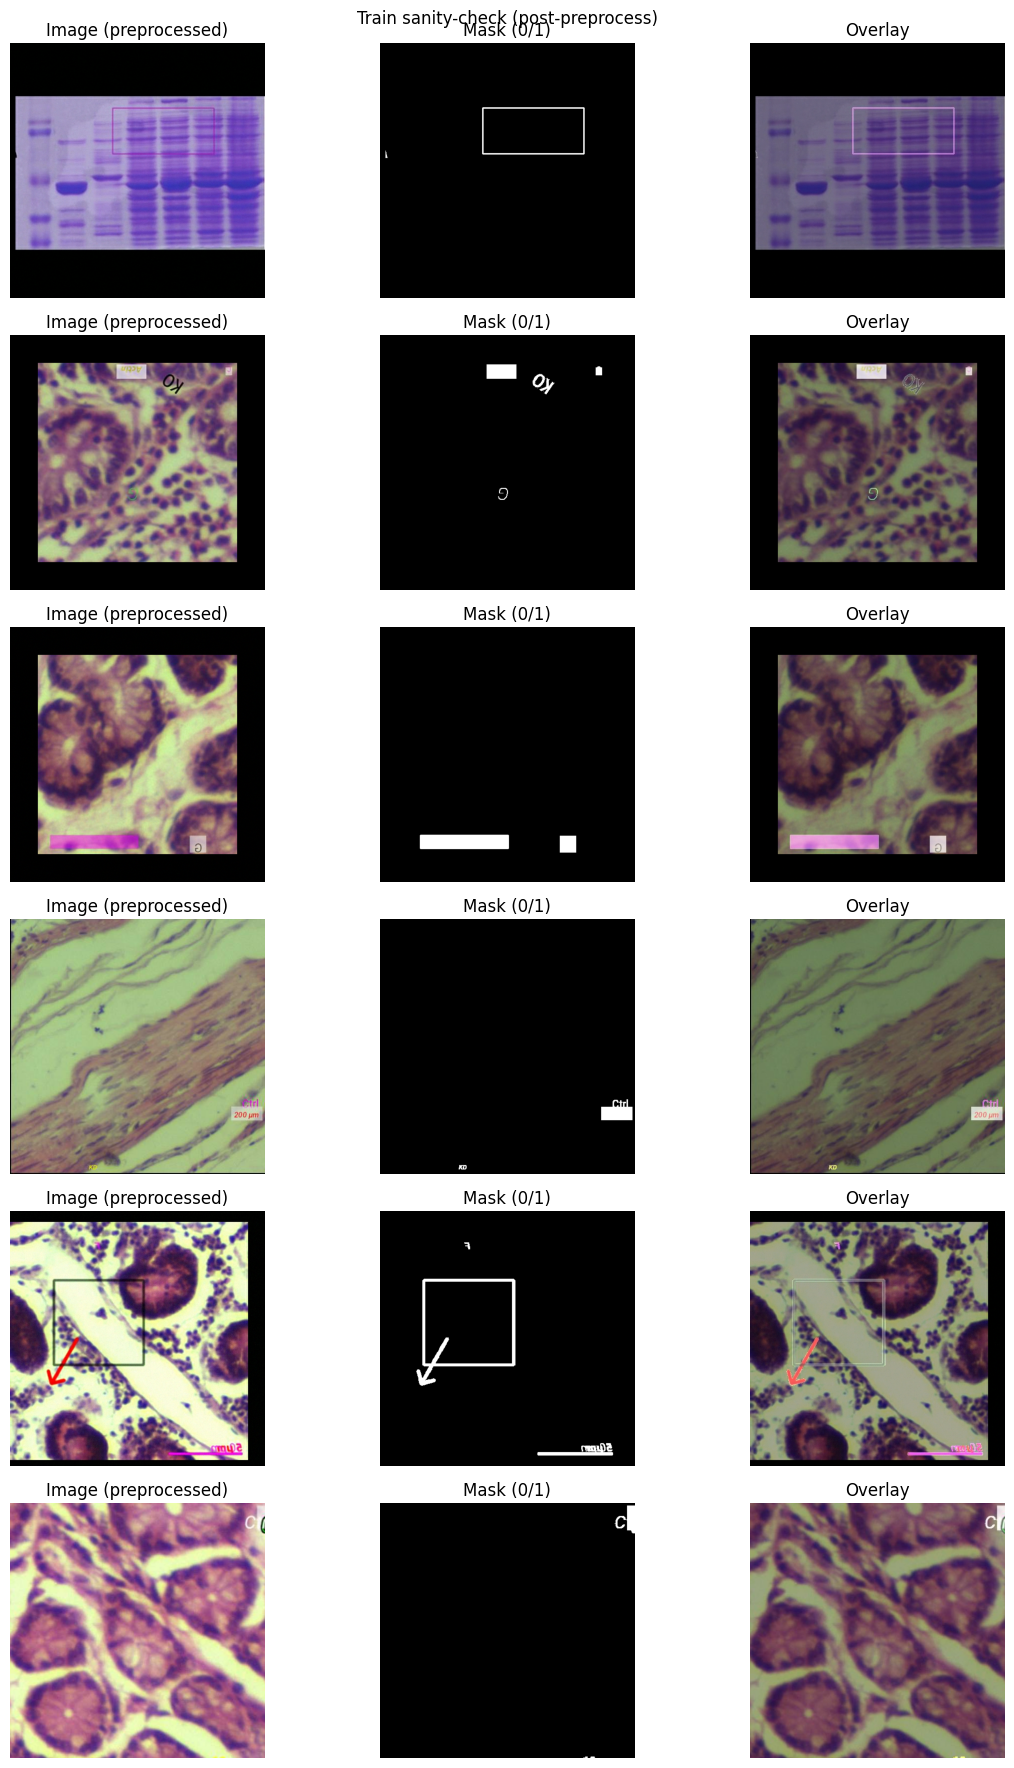

In [25]:
show_batch_from_dataset(train_ds, n=6, title="Train sanity-check (post-preprocess)")

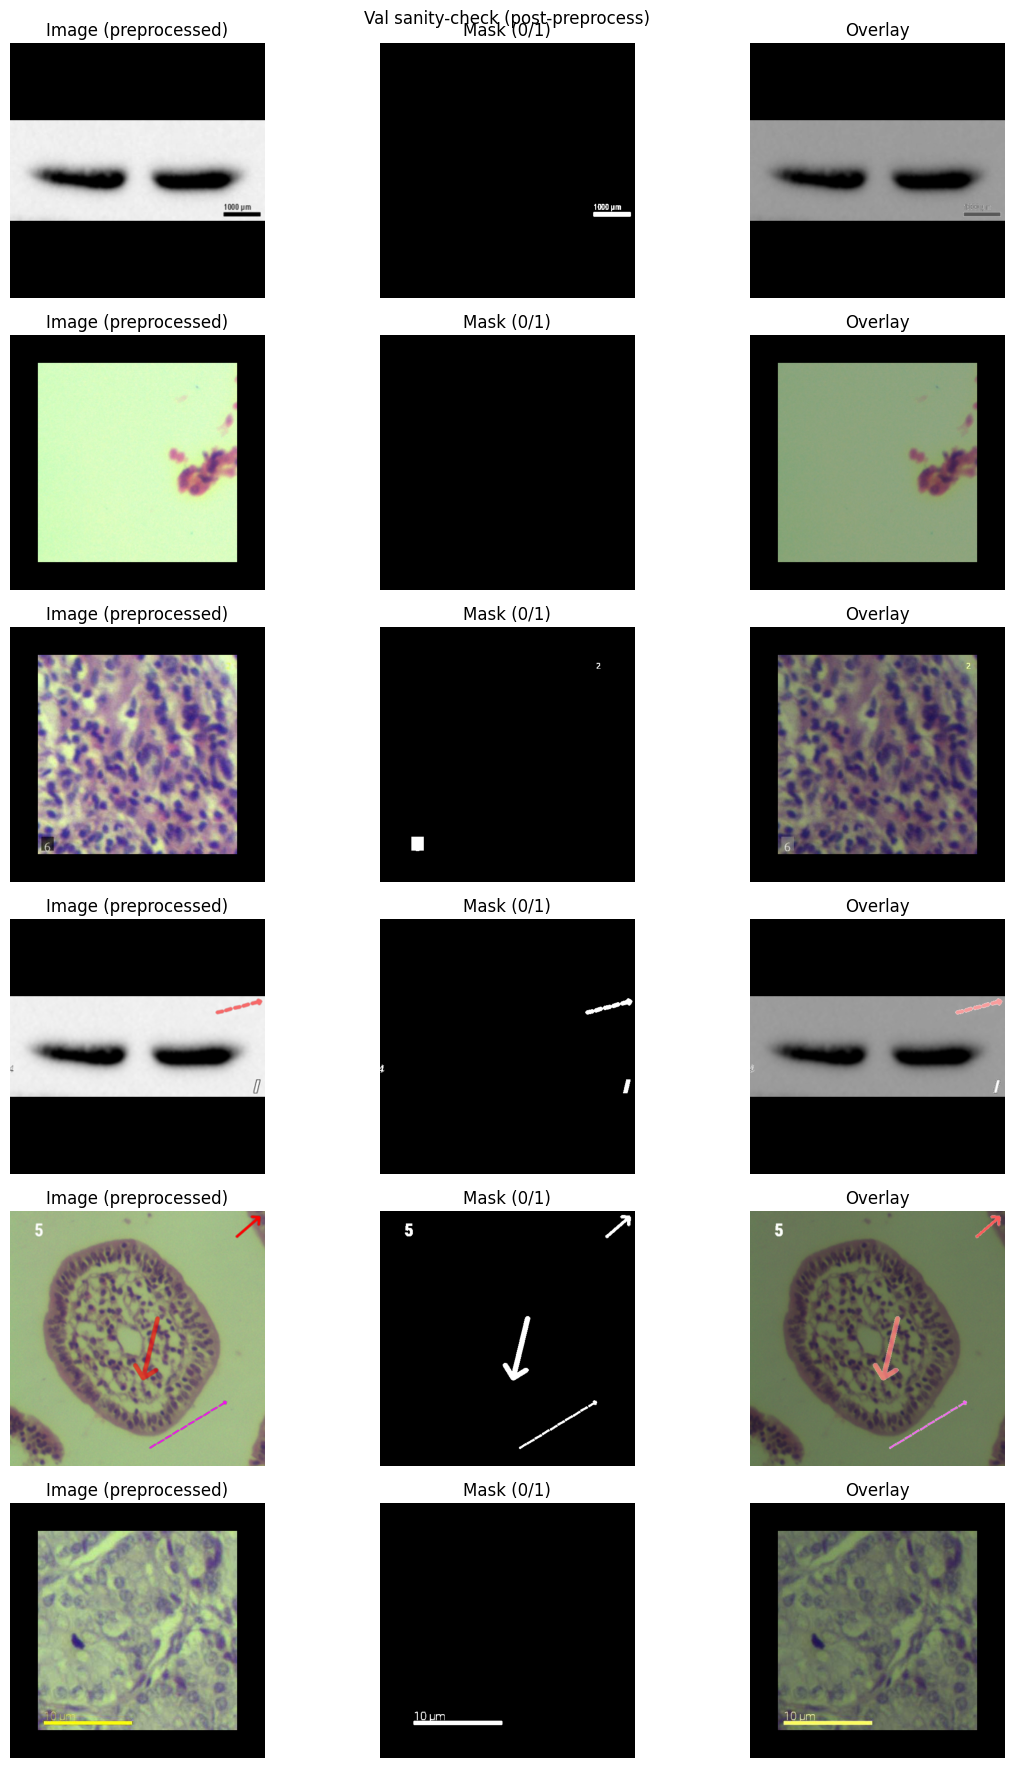

In [26]:
show_batch_from_dataset(val_ds,   n=6, title="Val sanity-check (post-preprocess)")

## 9.1 Callbacks: val-only metrics + prediction monitoring + loss weight schedule

In [27]:
import numpy as np
import keras
import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path

def _fmt_thr(t: float) -> str:
    # 0.5 -> 0p50
    return str(t).replace(".", "p")

def _edges_bool(mask_bool: np.ndarray) -> np.ndarray:
    """Compute a simple 4-neighborhood edge map from a boolean mask. mask: [B,H,W]"""
    # vertical xor
    dy = np.logical_xor(mask_bool[:, 1:, :], mask_bool[:, :-1, :])
    dy = np.pad(dy, ((0,0),(0,1),(0,0)), mode="constant", constant_values=False)
    dx = np.logical_xor(mask_bool[:, :, 1:], mask_bool[:, :, :-1])
    dx = np.pad(dx, ((0,0),(0,0),(0,1)), mode="constant", constant_values=False)
    return np.logical_or(dy, dx)

class LossWeightScheduler(keras.callbacks.Callback):
    """Linearly schedule w_edge from start -> end over warmup_epochs, then keep end."""
    def __init__(self, loss_obj: TotalSegLoss, schedule_cfg: dict):
        super().__init__()
        self.loss_obj = loss_obj
        self.cfg = schedule_cfg or {}
        self.enable = bool(self.cfg.get("enable", False))
        self.start = float(self.cfg.get("start_w_edge", 0.6))
        self.end = float(self.cfg.get("end_w_edge", 0.3))
        self.warmup_epochs = int(self.cfg.get("warmup_epochs", 3))

    def on_epoch_begin(self, epoch, logs=None):
        if not self.enable:
            return
        if self.warmup_epochs <= 1:
            w = self.end
        else:
            t = min(max(epoch / float(self.warmup_epochs - 1), 0.0), 1.0)
            w = self.start + t * (self.end - self.start)
        self.loss_obj.set_weights(w_edge=w)
        if logs is not None:
            logs["w_edge"] = float(w)

class ValThresholdMetricsCallback(keras.callbacks.Callback):
    """Compute multi-threshold segmentation metrics on validation only."""
    def __init__(self, val_ds, val_steps: int, thresholds, every_n_epochs: int, compute_edges: bool, out_csv: Path):
        super().__init__()
        self.val_ds = val_ds
        self.val_steps = int(max(1, val_steps))
        self.thresholds = [float(t) for t in thresholds]
        self.every_n_epochs = int(max(1, every_n_epochs))
        self.compute_edges = bool(compute_edges)
        self.out_csv = Path(out_csv)

        self.out_csv.parent.mkdir(parents=True, exist_ok=True)
        if not self.out_csv.exists():
            cols = ["epoch"]
            for t in self.thresholds:
                ts = _fmt_thr(t)
                cols += [f"precision_t{ts}", f"recall_t{ts}", f"f1_t{ts}", f"iou_t{ts}", f"dice_t{ts}"]
            cols += ["pred_fg_ratio_t0p50", "gt_fg_ratio"]
            if self.compute_edges:
                cols += ["edge_dice_t0p50"]
            self.out_csv.write_text(",".join(cols) + "\n", encoding="utf-8")

    def on_epoch_end(self, epoch, logs=None):
        if (epoch % self.every_n_epochs) != 0:
            return

        eps = 1e-9
        # accumulators per threshold
        agg = {t: {"tp": 0, "fp": 0, "fn": 0} for t in self.thresholds}
        total_px = 0
        total_gt_fg = 0
        total_pred_fg_t05 = 0
        edge_inter = 0
        edge_sum = 0

        it = iter(self.val_ds)
        for _ in range(self.val_steps):
            x, y = next(it)  # tf tensors
            # Use predict_on_batch for backend-friendly execution; returns numpy
            logits = self.model.predict_on_batch(x)
            # Convert y to numpy
            y_np = y.numpy().astype(np.uint8)  # [B,H,W,1]
            yb = (y_np[..., 0] > 0)

            # probs fg
            # logits: [B,H,W,C]
            # stable softmax
            logits_f = logits.astype(np.float32)
            exp = np.exp(logits_f - logits_f.max(axis=-1, keepdims=True))
            probs = exp / (exp.sum(axis=-1, keepdims=True) + eps)
            pfg = probs[..., 1]  # [B,H,W]

            total_px += int(np.prod(yb.shape))
            total_gt_fg += int(yb.sum())

            for t in self.thresholds:
                pred = (pfg > t)
                tp = int(np.logical_and(pred, yb).sum())
                fp = int(np.logical_and(pred, np.logical_not(yb)).sum())
                fn = int(np.logical_and(np.logical_not(pred), yb).sum())
                agg[t]["tp"] += tp
                agg[t]["fp"] += fp
                agg[t]["fn"] += fn

            # ratios at 0.5
            pred05 = (pfg > 0.5)
            total_pred_fg_t05 += int(pred05.sum())

            if self.compute_edges:
                e_true = _edges_bool(yb)
                e_pred = _edges_bool(pred05)
                edge_inter += int(np.logical_and(e_true, e_pred).sum())
                edge_sum += int(e_true.sum() + e_pred.sum())

        # finalize
        row = {"epoch": epoch}
        for t in self.thresholds:
            tp = agg[t]["tp"]; fp = agg[t]["fp"]; fn = agg[t]["fn"]
            prec = tp / (tp + fp + eps)
            rec  = tp / (tp + fn + eps)
            f1   = 2 * prec * rec / (prec + rec + eps)
            iou  = tp / (tp + fp + fn + eps)
            dice = 2 * tp / (2 * tp + fp + fn + eps)

            ts = _fmt_thr(t)
            row[f"precision_t{ts}"] = prec
            row[f"recall_t{ts}"] = rec
            row[f"f1_t{ts}"] = f1
            row[f"iou_t{ts}"] = iou
            row[f"dice_t{ts}"] = dice

            # also push into logs so they appear in history/tensorboard
            if logs is not None:
                logs[f"val_precision_t{ts}"] = float(prec)
                logs[f"val_recall_t{ts}"] = float(rec)
                logs[f"val_f1_t{ts}"] = float(f1)
                logs[f"val_iou_t{ts}"] = float(iou)
                logs[f"val_dice_t{ts}"] = float(dice)

        pred_fg_ratio = total_pred_fg_t05 / (total_px + eps)
        gt_fg_ratio = total_gt_fg / (total_px + eps)
        row["pred_fg_ratio_t0p50"] = pred_fg_ratio
        row["gt_fg_ratio"] = gt_fg_ratio
        if logs is not None:
            logs["val_pred_fg_ratio_t0p50"] = float(pred_fg_ratio)
            logs["val_gt_fg_ratio"] = float(gt_fg_ratio)

        if self.compute_edges:
            edge_dice = (2 * edge_inter) / (edge_sum + eps)
            row["edge_dice_t0p50"] = edge_dice
            if logs is not None:
                logs["val_edge_dice_t0p50"] = float(edge_dice)

        # append CSV
        # preserve column order by reading header
        header = self.out_csv.read_text(encoding="utf-8").splitlines()[0].split(",")
        values = []
        for k in header:
            v = row.get(k, "")
            values.append(str(v))
        with open(self.out_csv, "a", encoding="utf-8") as f:
            f.write(",".join(values) + "\n")

class PredMonitorCallback(keras.callbacks.Callback):
    """Save ghost overlays, diff maps, and zoomed patches for a fixed val batch."""
    def __init__(self, val_ds, run_dir: Path, num_samples=8, every_n_epochs=1, threshold=0.5, zoom_cfg=None):
        super().__init__()
        self.val_ds = val_ds
        self.run_dir = Path(run_dir)
        self.num_samples = int(num_samples)
        self.every_n_epochs = int(max(1, every_n_epochs))
        self.threshold = float(threshold)
        self.zoom_cfg = zoom_cfg or {}
        self.x0 = None
        self.y0 = None

    def on_train_begin(self, logs=None):
        x, y = next(iter(self.val_ds))
        x = x.numpy().astype(np.float32)
        y = y.numpy().astype(np.uint8)
        self.x0 = x[: self.num_samples]
        self.y0 = y[: self.num_samples]

    def _save_one(self, out_dir: Path, i: int, img255: np.ndarray, gt: np.ndarray, pfg: np.ndarray):
        pred = (pfg > self.threshold)
        gt_b = (gt > 0)

        # Ghost overlay
        fig = plt.figure(figsize=(6, 6))
        plt.imshow(np.clip(img255 / 255.0, 0, 1))
        plt.imshow(pred, alpha=0.35)
        plt.title(f"ghost pred@{self.threshold:.2f}")
        plt.axis("off")
        fig.savefig(out_dir / f"sample_{i:02d}_ghost.png", bbox_inches="tight", dpi=160)
        plt.close(fig)

        # Diff map (FP/FN)
        fp = np.logical_and(pred, np.logical_not(gt_b))
        fn = np.logical_and(np.logical_not(pred), gt_b)
        diff = np.zeros((gt_b.shape[0], gt_b.shape[1], 3), dtype=np.float32)
        diff[fp] = np.array([1.0, 0.0, 0.0], dtype=np.float32)  # red
        diff[fn] = np.array([0.0, 0.0, 1.0], dtype=np.float32)  # blue

        fig = plt.figure(figsize=(6, 6))
        plt.imshow(np.clip(img255 / 255.0, 0, 1))
        plt.imshow(diff, alpha=0.45)
        plt.title("diff (FP=red, FN=blue)")
        plt.axis("off")
        fig.savefig(out_dir / f"sample_{i:02d}_diff.png", bbox_inches="tight", dpi=160)
        plt.close(fig)

        # Zoom patches around GT positives (and fallback to union)
        if self.zoom_cfg.get("enable", False):
            pad = int(self.zoom_cfg.get("pad", 24))
            patch = int(self.zoom_cfg.get("patch_size", 256))

            mask = gt_b
            if mask.sum() == 0:
                mask = np.logical_or(gt_b, pred)

            if mask.sum() > 0:
                ys, xs = np.where(mask)
                y0, y1 = ys.min(), ys.max()
                x0, x1 = xs.min(), xs.max()
                y0 = max(0, y0 - pad); x0 = max(0, x0 - pad)
                y1 = min(mask.shape[0]-1, y1 + pad); x1 = min(mask.shape[1]-1, x1 + pad)

                crop_img = img255[y0:y1+1, x0:x1+1]
                crop_gt = gt_b[y0:y1+1, x0:x1+1]
                crop_pred = pred[y0:y1+1, x0:x1+1]

                # Resize for viewing
                crop_img_r = tf.image.resize(crop_img[None, ...], (patch, patch), method="bilinear").numpy()[0]
                crop_m_r = tf.image.resize(crop_gt.astype(np.float32)[None, ..., None], (patch, patch), method="nearest").numpy()[0, ..., 0] > 0.5
                crop_p_r = tf.image.resize(crop_pred.astype(np.float32)[None, ..., None], (patch, patch), method="nearest").numpy()[0, ..., 0] > 0.5

                fig = plt.figure(figsize=(6, 6))
                plt.imshow(np.clip(crop_img_r / 255.0, 0, 1))
                plt.imshow(crop_p_r, alpha=0.35)
                plt.title("zoom pred")
                plt.axis("off")
                fig.savefig(out_dir / f"sample_{i:02d}_zoom_pred.png", bbox_inches="tight", dpi=160)
                plt.close(fig)

                fig = plt.figure(figsize=(6, 6))
                plt.imshow(np.clip(crop_img_r / 255.0, 0, 1))
                plt.imshow(crop_m_r, alpha=0.35)
                plt.title("zoom gt")
                plt.axis("off")
                fig.savefig(out_dir / f"sample_{i:02d}_zoom_gt.png", bbox_inches="tight", dpi=160)
                plt.close(fig)

    def on_epoch_end(self, epoch, logs=None):
        if (epoch % self.every_n_epochs) != 0:
            return

        out_dir = self.run_dir / "viz" / f"epoch_{epoch:03d}"
        out_dir.mkdir(parents=True, exist_ok=True)

        logits = self.model.predict_on_batch(self.x0)  # numpy
        logits_f = logits.astype(np.float32)
        exp = np.exp(logits_f - logits_f.max(axis=-1, keepdims=True))
        probs = exp / (exp.sum(axis=-1, keepdims=True) + 1e-9)
        pfg = probs[..., 1]  # [B,H,W]

        for i in range(self.x0.shape[0]):
            img = self.x0[i]
            gt = self.y0[i, ..., 0]
            self._save_one(out_dir, i, img, gt, pfg[i])


## 10: Train

In [ ]:
# ----------------------------
# Train
# ----------------------------
bs = CONFIG["train"]["batch_size"]
steps_per_epoch = CONFIG["train"]["steps_per_epoch"] or max(1, n_train // bs)
val_steps = CONFIG["train"]["val_steps"] or max(1, n_val // bs)

epochs = int(CONFIG["train"]["epochs"])
total_steps = int(steps_per_epoch * epochs)

print("n_train:", n_train, "steps/epoch:", steps_per_epoch)
print("n_val  :", n_val,   "val_steps :", val_steps)
print("epochs :", epochs, "total_steps:", total_steps)

# Run folder (repro + clean outputs)
run_dir = make_run_dir(CONFIG)
print("Run dir:", run_dir)

write_json(run_dir / "config.json", CONFIG)
write_json(run_dir / "env.json", collect_env_info())

# Build model
model = build_segmenter(CONFIG)

# Loss + optimizer
loss_obj = make_total_loss(CONFIG["loss"])
opt = make_optimizer(CONFIG["train"], total_steps=total_steps)

model.compile(
    optimizer=opt,
    loss=loss_obj,
    metrics=[
        DiceMetric(eps=CONFIG["loss"]["eps"]),
        IoUMetric(eps=CONFIG["loss"]["eps"]),
    ],
    steps_per_execution=int(CONFIG["train"].get("steps_per_execution", 1)),
)

# Callbacks
callbacks = []

# Save best + last
callbacks.append(
    keras.callbacks.ModelCheckpoint(
        filepath=str(run_dir / "checkpoints" / "best.keras"),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False,
        mode="min",
    )
)
callbacks.append(
    keras.callbacks.ModelCheckpoint(
        filepath=str(run_dir / "checkpoints" / "last.keras"),
        save_best_only=False,
        save_weights_only=False,
        save_freq="epoch",
    )
)

# Optional: TensorBoard
if CONFIG.get("tb", {}).get("enable", False):
    callbacks.append(
        keras.callbacks.TensorBoard(
            log_dir=str(run_dir / "tb"),
            update_freq=CONFIG["tb"].get("update_freq", "epoch"),
            profile_batch=CONFIG["tb"].get("profile_batch", 0),
        )
    )

# Edge-weight schedule (boundary-first)
sch = CONFIG["loss"].get("edge_weight_schedule", {})
if sch.get("enable", False):
    callbacks.append(LossWeightScheduler(loss_obj, sch))

# Val-only multi-threshold metrics
vm = CONFIG.get("val_epoch_threshold_metrics", {})
if vm.get("enable", False):
    vm_steps = int(min(val_steps, max(1, int(vm.get("batches", val_steps)))))
    callbacks.append(
        ValThresholdMetricsCallback(
            val_ds=val_ds,
            val_steps=vm_steps,
            thresholds=vm.get("thresholds", [0.5]),
            every_n_epochs=vm.get("every_n_epochs", 1),
            compute_edges=vm.get("compute_edges", True),
            out_csv=run_dir / "val_threshold_metrics.csv",
        )
    )

# Prediction monitoring
vz = CONFIG.get("viz", {})
if vz.get("enable", False):
    callbacks.append(
        PredMonitorCallback(
            val_ds=val_ds,
            run_dir=run_dir,
            num_samples=vz.get("num_samples", 8),
            every_n_epochs=vz.get("every_n_epochs", 1),
            threshold=vz.get("threshold", 0.5),
            zoom_cfg=vz.get("zoom", {}),
        )
    )

# Early stopping (keep; schedule handles LR)
callbacks.append(
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
    )
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    steps_per_epoch=steps_per_epoch,
    validation_steps=val_steps,
    callbacks=callbacks,
)

# Save training history & final model
save_history_csv(history, run_dir / "history.csv")
model.save(run_dir / "checkpoints" / "final.keras")

print("Saved:", run_dir)

n_train: 10000 steps/epoch: 1250
n_val  : 2000 val_steps : 250
epochs : 25 total_steps: 31250
Run dir: /kaggle/working/runs/segformer_b3_20251226_185126_run
Epoch 1/25


E1226 18:53:44.753734     211 slow_operation_alarm.cc:73] Trying algorithm eng20{k2=8,k3=0} for conv (f32[768,3072,1,1]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,3072,128,128]{3,2,1,0}, f32[8,768,128,128]{3,2,1,0}), window={size=1x1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"} is taking a while...
E1226 18:53:45.092575      55 slow_operation_alarm.cc:140] The operation took 1.339023596s
Trying algorithm eng20{k2=8,k3=0} for conv (f32[768,3072,1,1]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,3072,128,128]{3,2,1,0}, f32[8,768,128,128]{3,2,1,0}), window={size=1x1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", backend_config={"operation_queue_id":"0","wait_on

 388/1250 ━━━━━━━━━━━━━━━━━━━━ 18:35 1s/step - dice: 0.0880 - iou: 0.0870 - loss: 1.2814

## 12) Post training -- Testing part

In [ ]:
import os, json, time, shutil, heapq
import numpy as np
from pathlib import Path
import keras

# ----------------------------
# Helpers: metrics + edges
# ----------------------------
def _softmax_fg_np(logits: np.ndarray) -> np.ndarray:
    """logits [B,H,W,2] -> fg prob [B,H,W]"""
    logits = logits.astype(np.float32)
    m = logits.max(axis=-1, keepdims=True)
    e = np.exp(logits - m)
    p = e / (e.sum(axis=-1, keepdims=True) + 1e-8)
    return p[..., 1]

def _edges_bool_np(mask_bool: np.ndarray) -> np.ndarray:
    """mask_bool: [H,W] bool -> edges [H,W] bool (4-neighborhood xor)"""
    dy = np.logical_xor(mask_bool[1:, :], mask_bool[:-1, :])
    dy = np.pad(dy, ((0,1),(0,0)), mode="constant", constant_values=False)
    dx = np.logical_xor(mask_bool[:, 1:], mask_bool[:, :-1])
    dx = np.pad(dx, ((0,0),(0,1)), mode="constant", constant_values=False)
    return np.logical_or(dy, dx)

def _counts(pred_bool: np.ndarray, gt_bool: np.ndarray):
    tp = int(np.logical_and(pred_bool, gt_bool).sum())
    fp = int(np.logical_and(pred_bool, ~gt_bool).sum())
    fn = int(np.logical_and(~pred_bool, gt_bool).sum())
    return tp, fp, fn

def _prf_iou_dice_from_counts(tp, fp, fn, eps=1e-8):
    precision = tp / (tp + fp + eps)
    recall    = tp / (tp + fn + eps)
    f1        = 2 * precision * recall / (precision + recall + eps)
    iou       = tp / (tp + fp + fn + eps)
    dice      = 2 * tp / (2 * tp + fp + fn + eps)
    return precision, recall, f1, iou, dice

def _to_u8_img(x):
    """x: [H,W,3] float (0..255) or (0..1) -> uint8"""
    x = np.asarray(x)
    if x.dtype != np.uint8:
        x = x.astype(np.float32)
        if x.max() <= 2.0:
            x = x * 255.0
        x = np.clip(x, 0.0, 255.0).astype(np.uint8)
    return x

def _ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)
    return p

def _write_json(path: Path, obj: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)

def _write_csv(path: Path, header, rows):
    path.parent.mkdir(parents=True, exist_ok=True)
    import csv
    with open(path, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(header)
        w.writerows(rows)

# ----------------------------
# Visualization: ghost + diff + zoom patches
# ----------------------------
def _save_viz_one(out_dir: Path, name: str, img_u8, gt_bool, prob_fg, thr: float, zoom_cfg: dict):
    import matplotlib.pyplot as plt

    pred_bool = (prob_fg >= thr)

    # Ghost overlay (pred in red tint)
    overlay = img_u8.copy().astype(np.float32)
    overlay[pred_bool] = 0.65 * overlay[pred_bool] + 0.35 * np.array([255, 0, 0], np.float32)

    # Diff map: TP=green, FP=red, FN=blue
    tp = np.logical_and(pred_bool, gt_bool)
    fp = np.logical_and(pred_bool, ~gt_bool)
    fn = np.logical_and(~pred_bool, gt_bool)

    diff = np.zeros_like(img_u8, dtype=np.uint8)
    diff[tp] = np.array([0, 255, 0], np.uint8)
    diff[fp] = np.array([255, 0, 0], np.uint8)
    diff[fn] = np.array([0, 0, 255], np.uint8)

    # Save side-by-side
    fig = plt.figure(figsize=(12, 4))
    ax1 = fig.add_subplot(1, 3, 1); ax1.imshow(img_u8); ax1.set_title("Image"); ax1.axis("off")
    ax2 = fig.add_subplot(1, 3, 2); ax2.imshow(overlay.astype(np.uint8)); ax2.set_title(f"Ghost pred (thr={thr:.2f})"); ax2.axis("off")
    ax3 = fig.add_subplot(1, 3, 3); ax3.imshow(diff); ax3.set_title("Diff (TP green / FP red / FN blue)"); ax3.axis("off")
    fig.tight_layout()
    fig.savefig(out_dir / f"{name}__ghost_diff.png", dpi=150)
    plt.close(fig)

    # Zoom patches around GT positives (random centers)
    if zoom_cfg.get("enable", False):
        rng = np.random.default_rng(int(zoom_cfg.get("seed", 1337)))
        ys, xs = np.where(gt_bool)
        if len(xs) > 0:
            patch = int(zoom_cfg.get("patch_size", 256))
            pad = int(zoom_cfg.get("pad", 24))
            max_p = int(zoom_cfg.get("max_patches", 6))
            H, W = gt_bool.shape
            picks = rng.choice(len(xs), size=min(max_p, len(xs)), replace=False)

            for j, k in enumerate(picks):
                cy, cx = int(ys[k]), int(xs[k])
                y0 = max(0, cy - patch // 2); y1 = min(H, y0 + patch)
                x0 = max(0, cx - patch // 2); x1 = min(W, x0 + patch)
                # adjust if at border
                y0 = max(0, y1 - patch); x0 = max(0, x1 - patch)

                img_p = img_u8[y0:y1, x0:x1]
                gt_p  = gt_bool[y0:y1, x0:x1]
                pr_p  = pred_bool[y0:y1, x0:x1]

                # simple overlay for patch
                ov = img_p.copy().astype(np.float32)
                ov[pr_p] = 0.65 * ov[pr_p] + 0.35 * np.array([255, 0, 0], np.float32)
                # draw GT edges in green
                ge = _edges_bool_np(gt_p)
                ov[ge] = 0.6 * ov[ge] + 0.4 * np.array([0, 255, 0], np.float32)

                fig2 = plt.figure(figsize=(4, 4))
                plt.imshow(ov.astype(np.uint8))
                plt.title(f"Zoom {j+1}")
                plt.axis("off")
                fig2.tight_layout()
                fig2.savefig(out_dir / f"{name}__zoom_{j:02d}.png", dpi=150)
                plt.close(fig2)

# ----------------------------
# Main post-train runner
# ----------------------------
def run_post_train(run_dir: Path, val_ds, val_steps: int, cfg: dict):
    pcfg = cfg.get("post_train", {})
    if not pcfg.get("enable", False):
        print("[POST] disabled")
        return

    run_dir = Path(run_dir)
    out_post = _ensure_dir(run_dir / "post")
    out_analysis = _ensure_dir(run_dir / "analysis")
    out_worst = _ensure_dir(out_analysis / "worst")
    out_export = _ensure_dir(run_dir / "export")

    best_path = run_dir / "checkpoints" / "best.keras"
    if not best_path.exists():
        raise FileNotFoundError(f"Best checkpoint not found: {best_path}")

    # Load best
    print("[POST] Loading best:", best_path)
    best_model = keras.models.load_model(best_path, compile=False)

    max_batches = pcfg.get("max_val_batches", None)
    steps = int(val_steps if (max_batches is None) else min(val_steps, int(max_batches)))

    thresholds = np.array(pcfg.get("thresholds", [0.5]), dtype=np.float32).tolist()
    compute_edges = bool(pcfg.get("compute_edge_metrics", True))

    # Sweep accumulators
    sweep = {t: {"tp": 0, "fp": 0, "fn": 0, "tp_e": 0, "fp_e": 0, "fn_e": 0} for t in thresholds}

    # Worst-K heap (select by dice at worst_select_threshold)
    K = int(pcfg.get("worst_k", 50))
    t_worst = float(pcfg.get("worst_select_threshold", 0.5))
    worst_heap = []  # store (dice, idx, img_u8, gt_bool, prob_fg)
    idx_global = 0

    # Sanity stats
    total_px = 0
    total_gt_fg = 0

    print(f"[POST] Sweeping thresholds on {steps} val batches ...")
    it = val_ds.take(steps)

    for b, (x, y) in enumerate(it):
        # to numpy
        x_np = x.numpy() if hasattr(x, "numpy") else np.asarray(x)
        y_np = y.numpy() if hasattr(y, "numpy") else np.asarray(y)

        # predict logits -> fg prob
        logits = best_model.predict(x_np, verbose=0)
        prob_fg = _softmax_fg_np(np.asarray(logits))  # [B,H,W]

        gt = (y_np[..., 0] > 0)  # [B,H,W] bool

        # dataset stats
        total_px += int(gt.size)
        total_gt_fg += int(gt.sum())

        # threshold sweep counts (pixel-level)
        for t in thresholds:
            pred = (prob_fg >= float(t))
            # aggregate counts across batch
            tp = int(np.logical_and(pred, gt).sum())
            fp = int(np.logical_and(pred, ~gt).sum())
            fn = int(np.logical_and(~pred, gt).sum())
            sweep[t]["tp"] += tp
            sweep[t]["fp"] += fp
            sweep[t]["fn"] += fn

            if compute_edges:
                # edge maps per image, then aggregate
                tp_e = fp_e = fn_e = 0
                for i in range(gt.shape[0]):
                    ge = _edges_bool_np(gt[i])
                    pe = _edges_bool_np(pred[i])
                    a, c, d = _counts(pe, ge)
                    tp_e += a; fp_e += c; fn_e += d
                sweep[t]["tp_e"] += tp_e
                sweep[t]["fp_e"] += fp_e
                sweep[t]["fn_e"] += fn_e

        # worst-K selection (per-image dice at t_worst)
        pred_w = (prob_fg >= t_worst)
        for i in range(gt.shape[0]):
            tp, fp, fn = _counts(pred_w[i], gt[i])
            _, _, _, _, dice = _prf_iou_dice_from_counts(tp, fp, fn)
            # keep smallest dice => worst
            if len(worst_heap) < K:
                heapq.heappush(worst_heap, (-dice, idx_global, _to_u8_img(x_np[i]), gt[i].copy(), prob_fg[i].astype(np.float16)))
            else:
                if -dice > worst_heap[0][0]:
                    heapq.heapreplace(worst_heap, (-dice, idx_global, _to_u8_img(x_np[i]), gt[i].copy(), prob_fg[i].astype(np.float16)))
            idx_global += 1

    # Build sweep table
    rows = []
    best_score = -1.0
    best_t = float(thresholds[0])

    opt = pcfg.get("optimize_metric", "dice")
    w_combo = pcfg.get("combo_weights", {"dice": 0.7, "edge_dice": 0.3})
    w_d = float(w_combo.get("dice", 0.7))
    w_e = float(w_combo.get("edge_dice", 0.3))

    for t in thresholds:
        tp, fp, fn = sweep[t]["tp"], sweep[t]["fp"], sweep[t]["fn"]
        p, r, f1, iou, dice = _prf_iou_dice_from_counts(tp, fp, fn)

        edge_dice = np.nan
        if compute_edges:
            tp_e, fp_e, fn_e = sweep[t]["tp_e"], sweep[t]["fp_e"], sweep[t]["fn_e"]
            _, _, _, _, edge_dice = _prf_iou_dice_from_counts(tp_e, fp_e, fn_e)

        if opt == "dice":
            score = float(dice)
        elif opt == "edge_dice":
            score = float(edge_dice) if compute_edges else float(dice)
        else:  # combo
            ed = float(edge_dice) if (compute_edges and not np.isnan(edge_dice)) else 0.0
            score = w_d * float(dice) + w_e * ed

        if score > best_score:
            best_score = score
            best_t = float(t)

        rows.append([t, p, r, f1, iou, dice, edge_dice, score])

    _write_csv(
        out_post / "threshold_sweep.csv",
        header=["threshold", "precision", "recall", "f1", "iou", "dice", "edge_dice", "score"],
        rows=rows,
    )

    _write_json(out_post / "best_threshold.json", {
        "best_threshold": best_t,
        "optimize_metric": opt,
        "best_score": best_score,
        "compute_edge_metrics": compute_edges,
        "gt_fg_ratio": float(total_gt_fg / (total_px + 1e-8)),
    })

    print(f"[POST] Best threshold: {best_t:.2f} (score={best_score:.4f}, optimize={opt})")

    # Full-val metrics at best threshold
    # (We already have pixel-level totals at each threshold; reuse those at best_t)
    bt = best_t
    tp, fp, fn = sweep[bt]["tp"], sweep[bt]["fp"], sweep[bt]["fn"]
    p, r, f1, iou, dice = _prf_iou_dice_from_counts(tp, fp, fn)

    edge_dice = None
    if compute_edges:
        tp_e, fp_e, fn_e = sweep[bt]["tp_e"], sweep[bt]["fp_e"], sweep[bt]["fn_e"]
        _, _, _, _, edge_dice = _prf_iou_dice_from_counts(tp_e, fp_e, fn_e)
        edge_dice = float(edge_dice)

    full = {
        "threshold": float(bt),
        "precision": float(p),
        "recall": float(r),
        "f1": float(f1),
        "iou": float(iou),
        "dice": float(dice),
        "edge_dice": edge_dice,
    }
    _write_json(out_post / "val_metrics_full.json", full)

    # Dump Worst-K visualizations
    worst_sorted = sorted(worst_heap, key=lambda z: z[0])  # most negative dice first
    viz_thr_cfg = pcfg.get("viz_threshold", "best")
    viz_thr = float(best_t if (viz_thr_cfg == "best") else viz_thr_cfg)

    print(f"[POST] Writing worst-{len(worst_sorted)} visuals @thr={viz_thr:.2f} ...")
    zoom_cfg = pcfg.get("zoom", {})

    worst_rows = []
    for rank, (neg_dice_sel, idx, img_u8, gt_bool, prob_fg_f16) in enumerate(worst_sorted):
        prob_fg = prob_fg_f16.astype(np.float32)
        pred_bool = (prob_fg >= viz_thr)

        tp0, fp0, fn0 = _counts(pred_bool, gt_bool)
        _, _, _, _, dice_now = _prf_iou_dice_from_counts(tp0, fp0, fn0)

        ed_now = None
        if compute_edges:
            ge = _edges_bool_np(gt_bool)
            pe = _edges_bool_np(pred_bool)
            tp_e, fp_e, fn_e = _counts(pe, ge)
            _, _, _, _, ed = _prf_iou_dice_from_counts(tp_e, fp_e, fn_e)
            ed_now = float(ed)

        name = f"idx_{idx:07d}_rank_{rank:03d}"
        od = _ensure_dir(out_worst)
        _save_viz_one(od, name, img_u8, gt_bool, prob_fg, viz_thr, zoom_cfg)

        worst_rows.append([rank, idx, float(-neg_dice_sel), float(dice_now), ed_now])

    _write_csv(
        out_analysis / "worst_cases.csv",
        header=["rank", "sample_index", f"dice_at_select_thr_{t_worst:.2f}", f"dice_at_viz_thr_{viz_thr:.2f}", "edge_dice_at_viz_thr"],
        rows=worst_rows,
    )

    # Export package
    if pcfg.get("export", {}).get("enable", True):
        print("[POST] Exporting inference package ...")
        _ensure_dir(out_export)
    
        # Copy best model (best.keras can be a file OR a directory depending on format)
        dst_model = out_export / "model_best.keras"
    
        if dst_model.exists():
            if dst_model.is_dir():
                shutil.rmtree(dst_model)
            else:
                dst_model.unlink()
    
        if best_path.is_dir():
            shutil.copytree(best_path, dst_model)
        else:
            shutil.copy2(best_path, dst_model)
    
        _write_json(out_export / "threshold.json", {"threshold": float(best_t)})
        _write_json(out_export / "preprocess.json", {
            "target_size": int(cfg["data"]["target_size"]),
            "pad_mode": cfg["data"]["pad_mode"],
            "pad_value": float(cfg["data"]["pad_value"]),
            "note": "Images are expected as float32 0..255 before model call (matches training pipeline).",
        })
        _write_json(out_export / "labels.json", {"background": 0, "overlay": 1})

    # Speed benchmark (note: first predict compiles on JAX, so warmup)
    sp = pcfg.get("speed", {})
    if sp.get("enable", False):
        warm = int(sp.get("warmup_batches", 1))
        nbm = int(sp.get("batches", 10))
        steps_bm = min(steps, warm + nbm)

        print(f"[POST] Speed benchmark: warmup={warm} batches, measure={nbm} batches ...")
        times = []
        n_imgs = 0

        it2 = val_ds.take(steps_bm)
        for bi, (x, y) in enumerate(it2):
            x_np = x.numpy() if hasattr(x, "numpy") else np.asarray(x)
            t0 = time.perf_counter()
            _ = best_model.predict(x_np, verbose=0)
            t1 = time.perf_counter()

            if bi >= warm:
                times.append(t1 - t0)
                n_imgs += int(x_np.shape[0])

        if times:
            sec = float(np.sum(times))
            ms_per_img = 1000.0 * sec / max(1, n_imgs)
            _write_json(out_post / "speed_benchmark.json", {
                "measured_batches": nbm,
                "images": int(n_imgs),
                "total_seconds": sec,
                "ms_per_image": ms_per_img,
            })
            print(f"[POST] ms/img: {ms_per_img:.2f}")

    print("[POST] Done. Wrote:", out_post)

In [ ]:
# ----------------------------
# Call post-train
# ----------------------------
run_post_train(run_dir, val_ds, val_steps, CONFIG)